/tmp/ipykernel_1130/4083983262.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


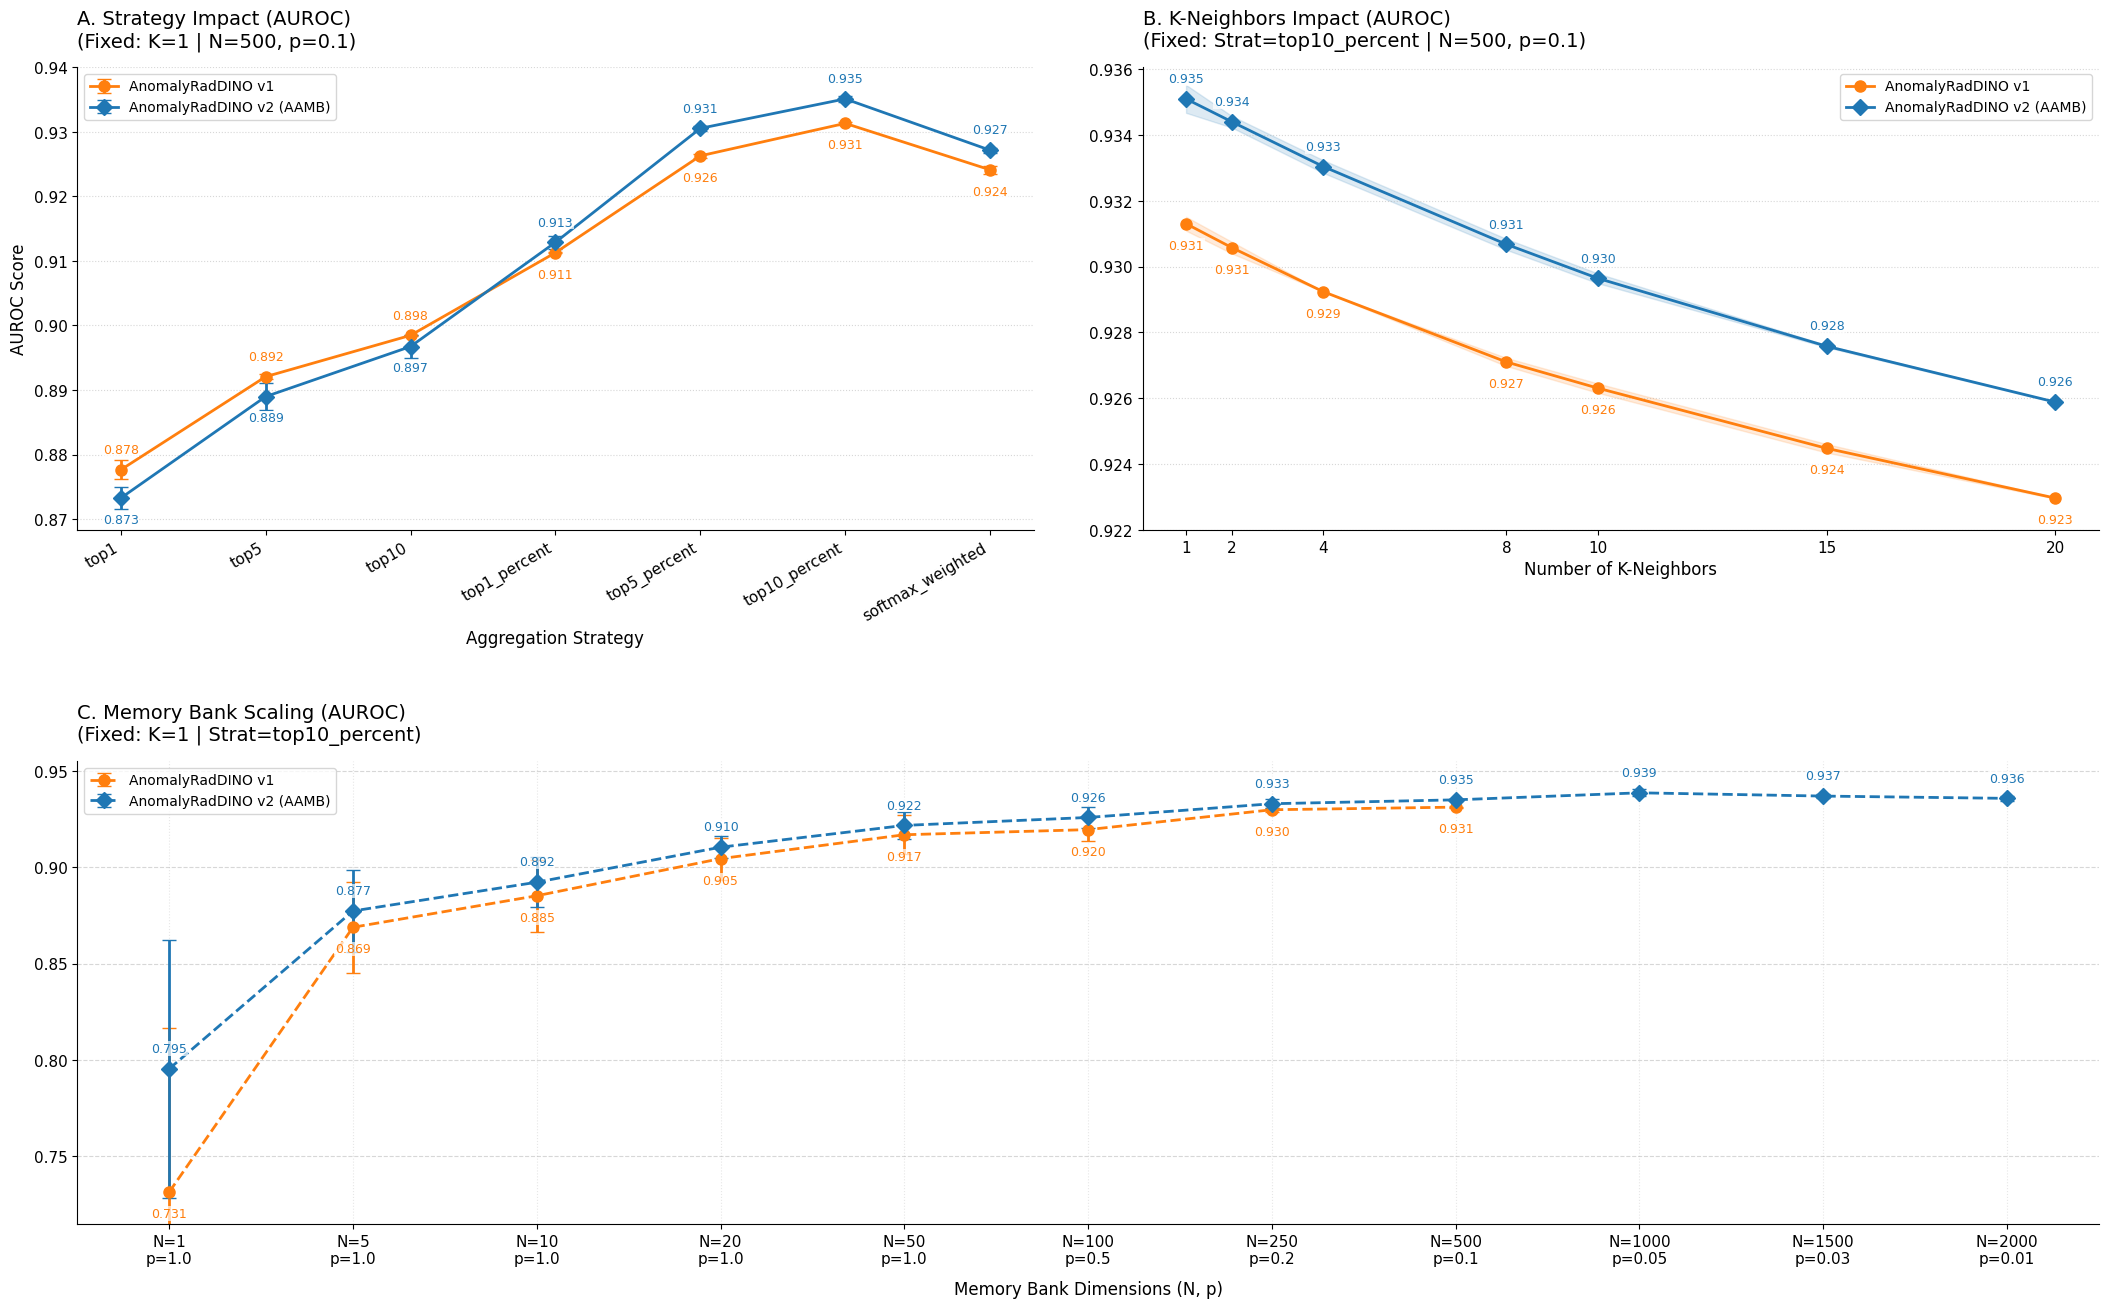

/tmp/ipykernel_1130/4083983262.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


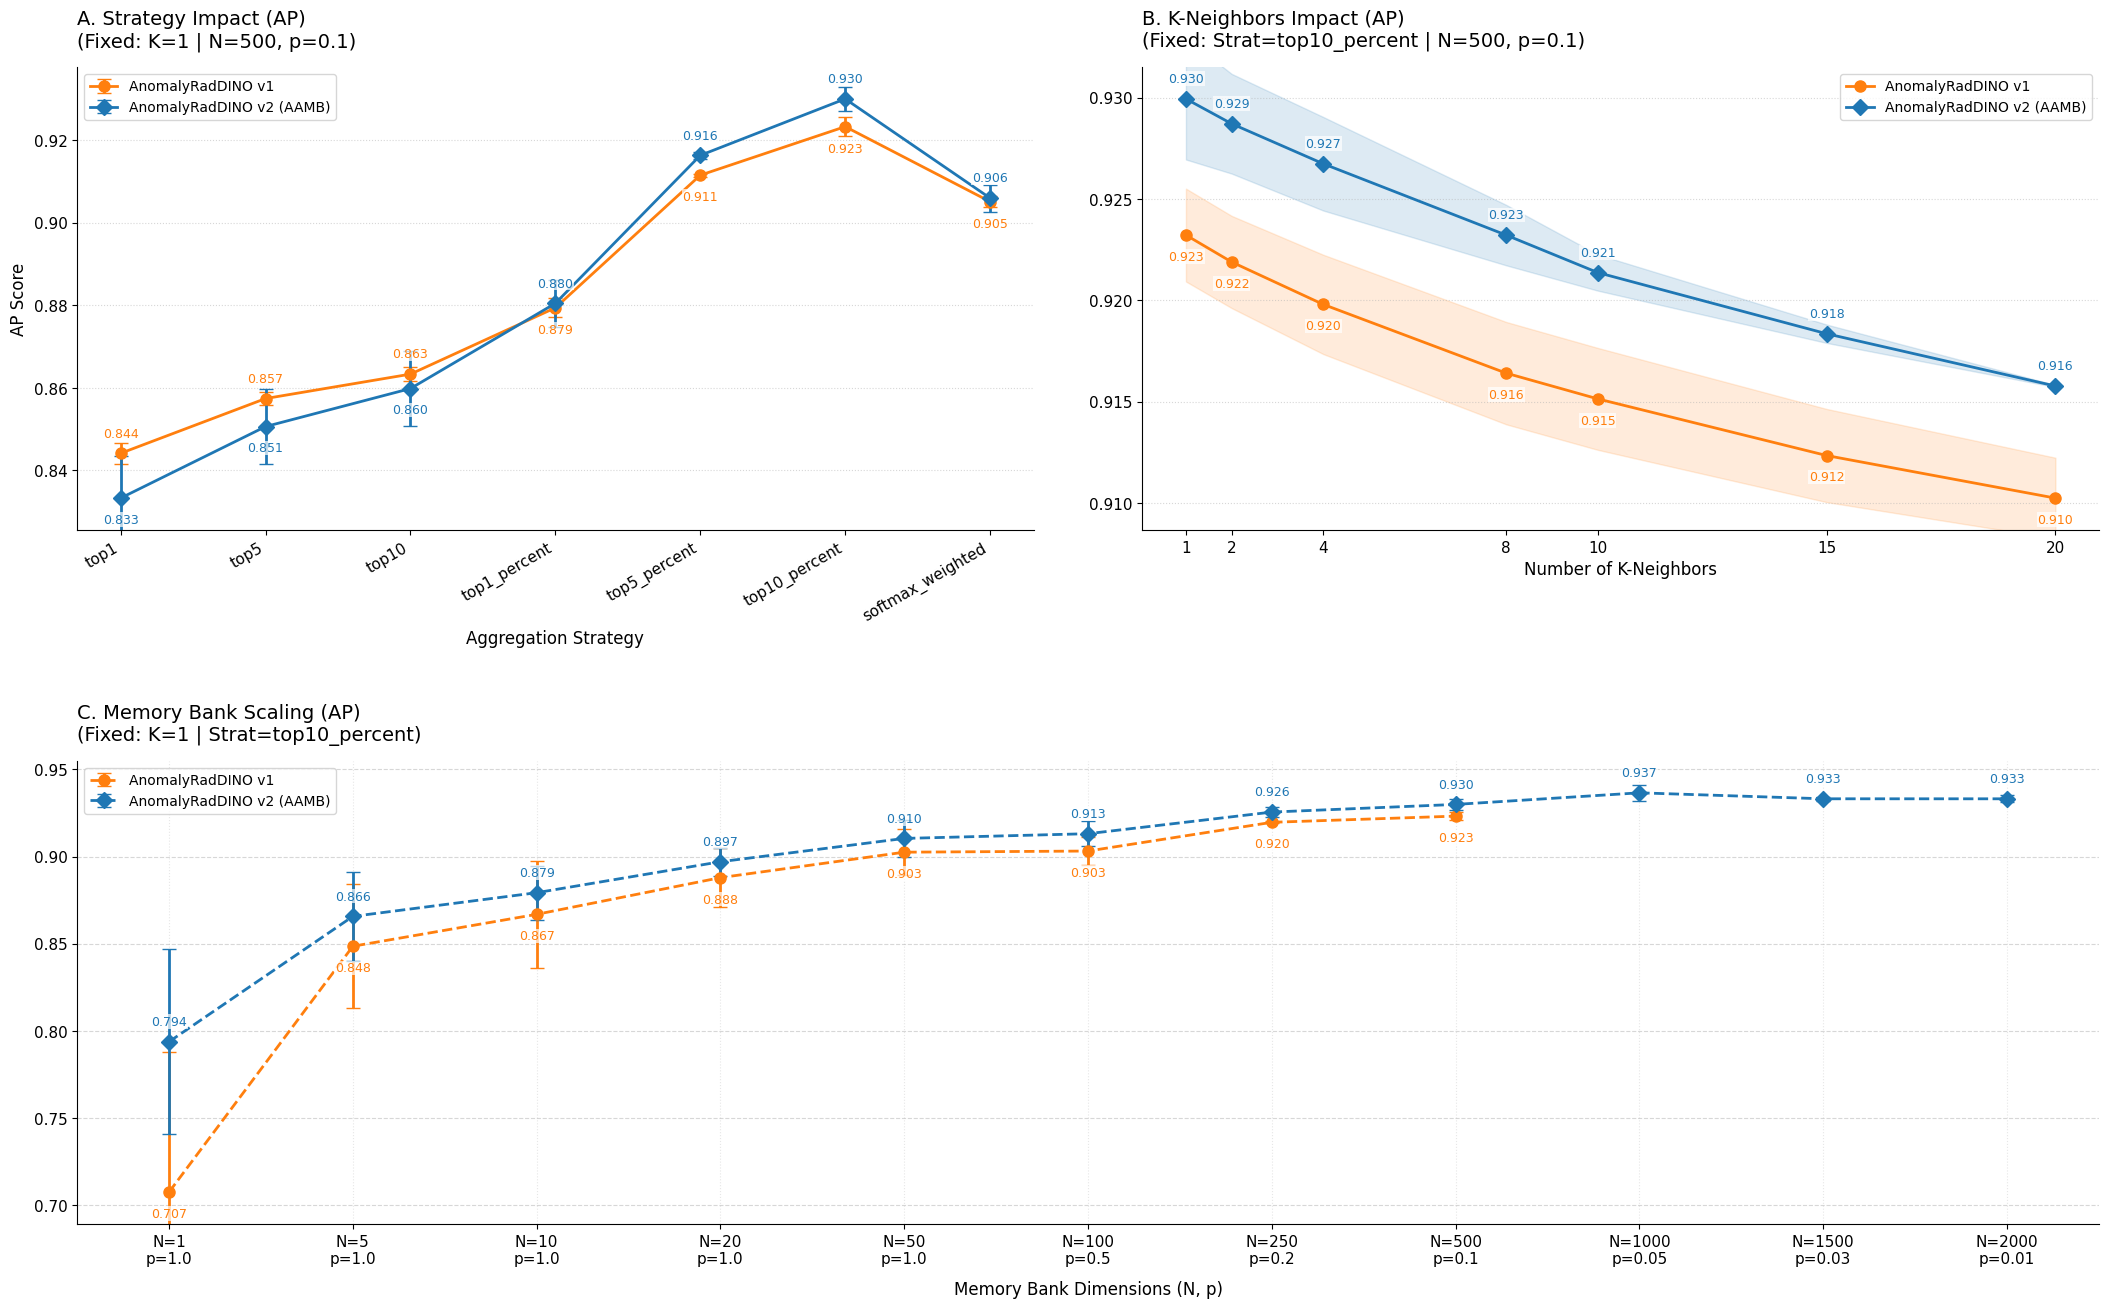

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

# ==========================================
# 1. CONFIGURATIONS & MAPPINGS
# ==========================================
ROOT_DIR = '/home/ca_uop_muoi/Applications/graduate_thesis/notebook/anomaly_detection/benchmarking/medianomaly/rsna'

models = ['global_bank', 'aamb']  # Thư mục cho AnomalyRadDINO v1 và v2 
data_versions = ['v1', 'v2', 'v3', 'v4', 'v5']      # 2 phiên bản dữ liệu/seed

case_info = {
    '8':  {'N': 1,    'p': 1.0},
    '9':  {'N': 5,    'p': 1.0},
    '10': {'N': 10,   'p': 1.0},
    '11': {'N': 20,   'p': 1.0},  # Cấu hình mới 2.0
    '1':  {'N': 50,   'p': 1.0}, 
    '2':  {'N': 100,  'p': 0.5}, 
    '3':  {'N': 250,  'p': 0.2}, 
    '4':  {'N': 500,  'p': 0.1}, 
    '5':  {'N': 1000, 'p': 0.05}, 
    '6':  {'N': 1500, 'p': 0.03}, 
    '7':  {'N': 2000, 'p': 0.01}
}

k_values = [1, 2, 4, 8, 10, 15, 20]
strategies = ["top1", "top5", "top10", "top1_percent", "top5_percent", "top10_percent", "softmax_weighted"]

FIXED_STRAT = 'top10_percent'
FIXED_K = 1
FIXED_CASE = '4' 

model_styles = {
    'global_bank': {'color': '#ff7f0e', 'label': 'AnomalyRadDINO v1', 'marker': 'o'},
    'aamb': {'color': '#1f77b4', 'label': 'AnomalyRadDINO v2 (AAMB)', 'marker': 'D'}
}

# Tiêu chuẩn thẩm mỹ Matplotlib
plt.rcParams.update({
    'font.family': 'sans-serif', 'axes.titlesize': 14, 'axes.titleweight': 'normal',
    'axes.titlelocation': 'left', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 12, 'xtick.labelsize': 11, 'ytick.labelsize': 11
})

# ==========================================
# 2. DATA EXTRACTION & AGGREGATION
# ==========================================
def calc_variation(x):
    """
    Tính toán độ dao động tùy theo số lượng seed thu thập được.
    - Nếu n = 2: Dùng Độ chênh bán phần (Max - Min) / 2
    - Nếu n > 2 (VD: 5 seeds): Dùng Độ lệch chuẩn mẫu (Sample Std, ddof=1)
    """
    n = len(x)
    if n <= 1:
        return 0.0
    elif n == 2:
        return (np.max(x) - np.min(x)) / 2.0
    else:
        # ddof=1 là chuẩn cho Sample Standard Deviation khi n khiêm tốn (như n=5)
        return np.std(x, ddof=1)

def load_all_benchmarks():
    raw_results = []
    
    for model in models:
        available_cases = ['8', '9', '10', '11', '1', '2', '3', '4'] 
        if model == 'aamb':
            available_cases.extend(['5', '6', '7'])  # V2 support large banks
            
        for cid in available_cases:
            for dv in data_versions:
                # Path mới: /benchmarking/medianomaly/vindrcxr / v1 / aamb / inference_case_x.npz
                path = os.path.join(ROOT_DIR, dv, model, f'inference_case_{cid}.npz')
                if not os.path.exists(path): 
                    continue
                    
                data = np.load(path)
                y_true = data['true_labels']
                
                for k in k_values:
                    for strat in strategies:
                        key = f"k_{k}_{strat}"
                        if key in data:
                            y_score = data[key]
                            raw_results.append({
                                'Model': model, 
                                'Data_Version': dv,
                                'Case_ID': cid,
                                'N': case_info[cid]['N'],
                                'p': case_info[cid]['p'],
                                'K': k, 
                                'Strategy': strat,
                                'AUROC': roc_auc_score(y_true, y_score),
                                'AP': average_precision_score(y_true, y_score)
                            })
    return pd.DataFrame(raw_results)

df_raw = load_all_benchmarks()
df_raw['Strategy'] = pd.Categorical(df_raw['Strategy'], categories=strategies, ordered=True)

# Lấy mean & std gom qua 2 trial (v1, v2)
df_agg = df_raw.groupby(['Model', 'Case_ID', 'N', 'p', 'K', 'Strategy'], observed=True).agg(
    AUROC_mean=('AUROC', 'mean'), AUROC_std=('AUROC', calc_variation),
    AP_mean=('AP', 'mean'), AP_std=('AP', calc_variation)
).reset_index().fillna(0)

# Sort theo trục N
df_agg = df_agg.sort_values(by=['Model', 'N', 'K', 'Strategy'])


# ==========================================
# 3. PLOTTING FUNCTIONS
# ==========================================
def set_ylim_tight(ax, y_values, margin_factor=0.08):
    if len(y_values) == 0: return
    lb, ub = np.min(y_values), np.max(y_values)
    ran = ub - lb if (ub - lb) > 0 else 0.01
    ax.set_ylim(max(0, lb - ran*margin_factor), min(1, ub + ran*margin_factor))

def annotate_point(ax, x, y, y_all_models_at_x, color):
    # Tránh đè Text Annotation
    is_top = y == max(y_all_models_at_x)
    offset_y = 12 if is_top else -18
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, offset_y), 
                ha='center', fontsize=9, color=color, weight='normal',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0.5))

def draw_vs_strategy(ax, metric, letter):
    m_mean, m_std = f'{metric}_mean', f'{metric}_std'
    core_y_values = []
    dict_series = {}
    for model in models:
        st_data = df_agg[(df_agg['Model'] == model) & (df_agg['Case_ID'] == FIXED_CASE) & (df_agg['K'] == FIXED_K)]
        if not st_data.empty: dict_series[model] = st_data

    for model, st_data in dict_series.items():
        style = model_styles[model]
        ax.errorbar(st_data['Strategy'], st_data[m_mean], yerr=st_data[m_std], 
                    fmt=style['marker'], color=style['color'], ls='-', lw=2, capsize=5, ms=8, label=style['label'])
        
        for i, (x, y) in enumerate(zip(st_data['Strategy'], st_data[m_mean])):
            y_all_models_at_x = [d[m_mean].iloc[i] for d in dict_series.values()]
            annotate_point(ax, x, y, y_all_models_at_x, style['color'])
            
        core_y_values.extend(st_data[m_mean])
        
    set_ylim_tight(ax, core_y_values)
    ax.set_title(f'{letter}. Strategy Impact ({metric})\n(Fixed: K={FIXED_K} | N={case_info[FIXED_CASE]["N"]}, p={case_info[FIXED_CASE]["p"]})', pad=15)
    ax.set_xlabel('Aggregation Strategy')
    ax.set_ylabel(f'{metric} Score')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(loc='best')
    ax.grid(axis='y', ls=':', alpha=0.5)

def draw_vs_k(ax, metric, letter):
    m_mean, m_std = f'{metric}_mean', f'{metric}_std'
    core_y_values = []
    dict_series = {}
    for model in models:
        k_data = df_agg[(df_agg['Model'] == model) & (df_agg['Case_ID'] == FIXED_CASE) & (df_agg['Strategy'] == FIXED_STRAT)]
        if not k_data.empty: dict_series[model] = k_data
            
    for model, k_data in dict_series.items():
        style = model_styles[model]
        ax.plot(k_data['K'], k_data[m_mean], marker=style['marker'], color=style['color'], ls='-', lw=2, ms=8, label=style['label'])
        ax.fill_between(k_data['K'], k_data[m_mean] - k_data[m_std], k_data[m_mean] + k_data[m_std], color=style['color'], alpha=0.15)
        
        for i, (x, y) in enumerate(zip(k_data['K'], k_data[m_mean])):
            y_all_models_at_x = [d[m_mean].iloc[i] for d in dict_series.values()]
            annotate_point(ax, x, y, y_all_models_at_x, style['color'])

        core_y_values.extend(k_data[m_mean])
        
    set_ylim_tight(ax, core_y_values)
    ax.set_title(f'{letter}. K-Neighbors Impact ({metric})\n(Fixed: Strat={FIXED_STRAT} | N={case_info[FIXED_CASE]["N"]}, p={case_info[FIXED_CASE]["p"]})', pad=15)
    ax.set_xlabel('Number of K-Neighbors')
    ax.set_xticks(k_values)
    ax.legend(loc='best')
    ax.grid(axis='y', ls=':', alpha=0.5)

def draw_vs_scale(ax, metric, letter):
    m_mean, m_std = f'{metric}_mean', f'{metric}_std'
    core_y_values = [] 
    
    unique_n = np.sort(df_agg['N'].unique())
    x_positions = np.arange(len(unique_n))
    n_to_x = {n: i for i, n in enumerate(unique_n)}
    
    dict_series = {}
    for model in models:
        n_data = df_agg[(df_agg['Model'] == model) & (df_agg['K'] == FIXED_K) & (df_agg['Strategy'] == FIXED_STRAT)]
        if not n_data.empty: dict_series[model] = n_data

    for model, n_data in dict_series.items():
        style = model_styles[model]
        mapped_x = n_data['N'].map(n_to_x)
        ax.errorbar(mapped_x, n_data[m_mean], yerr=n_data[m_std], 
                    fmt=style['marker'], color=style['color'], ls='--', lw=2, capsize=5, ms=8, label=style['label'])
        
        for i, (x, y) in enumerate(zip(mapped_x, n_data[m_mean])):
            original_n = list(n_to_x.keys())[list(n_to_x.values()).index(x)]
            y_all = [d[d['N'] == original_n][m_mean].iloc[0] for d in dict_series.values() if not d[d['N'] == original_n].empty]
            annotate_point(ax, x, y, y_all, style['color'])
            
        core_y_values.extend(n_data[m_mean])
        
    set_ylim_tight(ax, core_y_values)
    ax.set_title(f'{letter}. Memory Bank Scaling ({metric})\n(Fixed: K={FIXED_K} | Strat={FIXED_STRAT})', pad=15)
    
    x_labels = []
    for n_val in unique_n:
        p_val = df_agg[df_agg['N'] == n_val]['p'].iloc[0]
        x_labels.append(f"N={n_val}\np={p_val}")
        
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=0)
    ax.set_xlabel('Memory Bank Dimensions (N, p)', labelpad=10)
    ax.legend(loc='best')
    ax.grid(axis='y', ls='--', alpha=0.5)
    ax.grid(axis='x', ls=':', alpha=0.3)

# ==========================================
# 4. RENDER PLOTS
# ==========================================
fig_auroc = plt.figure(figsize=(22, 14))
gs = fig_auroc.add_gridspec(2, 2)
ax1 = fig_auroc.add_subplot(gs[0, 0]); draw_vs_strategy(ax1, 'AUROC', 'A')
ax2 = fig_auroc.add_subplot(gs[0, 1]); draw_vs_k(ax2, 'AUROC', 'B')
ax3 = fig_auroc.add_subplot(gs[1, :]); draw_vs_scale(ax3, 'AUROC', 'C')
plt.tight_layout(pad=4.0) 
plt.show()

fig_ap = plt.figure(figsize=(22, 14))
gs_ap = fig_ap.add_gridspec(2, 2)
ax4 = fig_ap.add_subplot(gs_ap[0, 0]); draw_vs_strategy(ax4, 'AP', 'A')
ax5 = fig_ap.add_subplot(gs_ap[0, 1]); draw_vs_k(ax5, 'AP', 'B')
ax6 = fig_ap.add_subplot(gs_ap[1, :]); draw_vs_scale(ax6, 'AP', 'C')
plt.tight_layout(pad=4.0)
plt.show()

In [3]:
# ==========================================
# 5. ABLATION STUDY CSV EXPORT (a ± b)
# ==========================================
ablation_models = [
    'global_bank',
    'aamb',
    'ablation_aamb/lung',
    'ablation_aamb/lung_heart',
    'ablation_aamb/lung_diaphragmatica',
    'ablation_aamb/lung_heart_diaphragmatica'
]

abl_records = []

print("Đang quét và tổng hợp dữ liệu Ablation...")
for model in ablation_models:
    for cid, info in case_info.items():
        # V1 (global_bank) bỏ qua các cases siêu lớn
        if model == 'global_bank' and cid in ['5', '6', '7']:
            continue
            
        for dv in data_versions:
            path = os.path.join(ROOT_DIR, dv, model, f'inference_case_{cid}.npz')
            if not os.path.exists(path): 
                continue
                
            data = np.load(path)
            y_true = data['true_labels']
            key = f"k_{FIXED_K}_{FIXED_STRAT}"
            
            if key in data:
                y_score = data[key]
                abl_records.append({
                    'Model': model,
                    'Case_ID': cid, 'N': info['N'], 'p': info['p'],
                    'AUROC': roc_auc_score(y_true, y_score),
                    'AP': average_precision_score(y_true, y_score)
                })

df_abl_raw = pd.DataFrame(abl_records)

if df_abl_raw.empty:
    print("Vui lòng kiểm tra lại đường dẫn ROOT_DIR, không tìm thấy file .npz hợp lệ.")
else:
    # Tính Mean & Std từ dataset raw
    df_abl_agg = df_abl_raw.groupby(['Model', 'Case_ID', 'N', 'p'], observed=True).agg(
        AUROC_mean=('AUROC', 'mean'), AUROC_std=('AUROC', calc_variation),
        AP_mean=('AP', 'mean'), AP_std=('AP', calc_variation)
    ).reset_index()

    # Định dạng String xuất File (a ± b)
    df_abl_agg['AUROC(±)'] = df_abl_agg.apply(lambda r: f"{r['AUROC_mean']:.4f} ± {r['AUROC_std']:.4f}", axis=1)
    df_abl_agg['AP(±)'] = df_abl_agg.apply(lambda r: f"{r['AP_mean']:.4f} ± {r['AP_std']:.4f}", axis=1)

    # Xoay DataFrame (Pivot Table)
    pivot_df = df_abl_agg.pivot_table(
        index=['N', 'p'],
        columns='Model',
        values=['AUROC(±)', 'AP(±)'],
        aggfunc='first'
    )

    # LÀM PHẲNG TÊN CỘT (Flatten MultiIndex)
    # Kết quả sẽ biến ('AUROC(±)', 'aamb') thành 'AUROC(±)_aamb'
    pivot_df.columns = [f"{col[0]}_{col[1]}" for col in pivot_df.columns.values]
    
    # Khôi phục N, p thành cột bình thường
    pivot_df = pivot_df.reset_index()

    # Căn chỉnh lại thứ tự Columns của Model cho khoa học từ Global -> AAMB Core -> Ablation Components
    ordered_models = [
        'global_bank', 'aamb', 'ablation_aamb/lung', 'ablation_aamb/lung_heart', 
        'ablation_aamb/lung_diaphragmatica', 'ablation_aamb/lung_heart_diaphragmatica'
    ]

    # Filter chỉ lấy những cột có dữ liệu thực tế tồn tại
    valid_cols = []
    
    # Gom AUROC trước
    for m in ordered_models:
        col_name = f"AUROC(±)_{m}"
        if col_name in pivot_df.columns:
            valid_cols.append(col_name)
            
    # Xong tới AP
    for m in ordered_models:
        col_name = f"AP(±)_{m}"
        if col_name in pivot_df.columns:
            valid_cols.append(col_name)

    # Tổ chức lại layout + Sắp xếp N tăng dần
    final_columns = ['N', 'p'] + valid_cols
    pivot_df = pivot_df[final_columns].sort_values(by='N')

    display(pivot_df)

    csv_path = 'rsna_ablation_results.csv'
    pivot_df.to_csv(csv_path, index=False)
    print(f"Đã xuất file báo cáo tại => {csv_path}")

Đang quét và tổng hợp dữ liệu Ablation...


,N,p,AUROC(±)_global_bank,AUROC(±)_aamb,AUROC(±)_ablation_aamb/lung,AUROC(±)_ablation_aamb/lung_heart,AUROC(±)_ablation_aamb/lung_diaphragmatica,AUROC(±)_ablation_aamb/lung_heart_diaphragmatica,AP(±)_global_bank,AP(±)_aamb,AP(±)_ablation_aamb/lung,AP(±)_ablation_aamb/lung_heart,AP(±)_ablation_aamb/lung_diaphragmatica,AP(±)_ablation_aamb/lung_heart_diaphragmatica
0,1,1.00,0.7312 ± 0.0853,0.7952 ± 0.0672,0.7665 ± 0.0883,0.7917 ± 0.0778,0.7770 ± 0.0817,0.7878 ± 0.0746,0.7073 ± 0.0802,0.7936 ± 0.0530,0.7629 ± 0.0707,0.7915 ± 0.0619,0.7730 ± 0.0678,0.7846 ± 0.0615
1,5,1.00,0.8688 ± 0.0238,0.8773 ± 0.0213,0.8636 ± 0.0295,0.8727 ± 0.0266,0.8765 ± 0.0217,0.8786 ± 0.0215,0.8485 ± 0.0355,0.8656 ± 0.0257,0.8479 ± 0.0272,0.8605 ± 0.0249,0.8636 ± 0.0250,0.8662 ± 0.0248
2,10,1.00,0.8852 ± 0.0187,0.8923 ± 0.0130,0.8857 ± 0.0143,0.8924 ± 0.0125,0.8905 ± 0.0166,0.8923 ± 0.0158,0.8668 ± 0.0306,0.8792 ± 0.0155,0.8696 ± 0.0168,0.8793 ± 0.0149,0.8753 ± 0.0202,0.8779 ± 0.0191
3,20,1.00,0.9045 ± 0.0109,0.9105 ± 0.0058,0.9084 ± 0.0047,0.9113 ± 0.0052,0.9117 ± 0.0058,0.9121 ± 0.0059,0.8879 ± 0.0171,0.8970 ± 0.0081,0.8939 ± 0.0080,0.8994 ± 0.0081,0.8961 ± 0.0081,0.8975 ± 0.0080
4,50,1.00,0.9169 ± 0.0101,0.9218 ± 0.0071,0.9213 ± 0.0075,0.9237 ± 0.0076,0.9238 ± 0.0069,0.9241 ± 0.0071,0.9025 ± 0.0131,0.9104 ± 0.0106,0.9085 ± 0.0123,0.9133 ± 0.0128,0.9120 ± 0.0097,0.9125 ± 0.0105
5,100,0.50,0.9196 ± 0.0060,0.9259 ± 0.0053,0.9266 ± 0.0056,0.9284 ± 0.0058,0.9280 ± 0.0055,0.9280 ± 0.0055,0.9032 ± 0.0079,0.9131 ± 0.0073,0.9124 ± 0.0088,0.9157 ± 0.0090,0.9152 ± 0.0077,0.9152 ± 0.0077
6,250,0.20,0.9299 ± 0.0010,0.9331 ± 0.0023,0.9332 ± 0.0030,0.9349 ± 0.0029,0.9349 ± 0.0017,0.9350 ± 0.0018,0.9197 ± 0.0005,0.9255 ± 0.0030,0.9265 ± 0.0052,0.9296 ± 0.0047,0.9274 ± 0.0028,0.9278 ± 0.0028
7,500,0.10,0.9313 ± 0.0002,0.9351 ± 0.0004,0.9352 ± 0.0025,0.9368 ± 0.0020,0.9368 ± 0.0004,0.9366 ± 0.0003,0.9232 ± 0.0023,0.9299 ± 0.0030,0.9307 ± 0.0060,0.9331 ± 0.0055,0.9318 ± 0.0023,0.9319 ± 0.0024
8,1000,0.05,NaN,0.9387 ± 0.0018,0.9365 ± 0.0022,0.9382 ± 0.0023,0.9397 ± 0.0017,0.9400 ± 0.0014,NaN,0.9366 ± 0.0045,0.9343 ± 0.0050,0.9369 ± 0.0053,0.9379 ± 0.0042,0.9381 ± 0.0042
9,1500,0.03,NaN,0.9370 ± 0.0008,0.9351 ± 0.0010,0.9362 ± 0.0013,0.9387 ± 0.0011,0.9382 ± 0.0009,NaN,0.9332 ± 0.0013,0.9329 ± 0.0019,0.9347 ± 0.0021,0.9354 ± 0.0015,0.9347 ± 0.0016


Đã xuất file báo cáo tại => rsna_ablation_results.csv
